In [ ]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

import autoslo.filesystem.path_utils as pu
from autoslo.filesystem.logos_export import logos_df
from autoslo.filesystem.structured_log import StructuredLog
from autoslo.slo.slo_resolver import SloResolver
from autoslo.config.component_configs import SloResolverConfig
from autoslo.filesystem.yaml_helpers import load_yaml
from logos import Logos
from IPython.display import Image
from logos.preparation.prepared_variable_name import PreparedVariableName
from logos.parsing.parsed_variable_name import ParsedVariableName
from logos.parsing.tag_utils import name_of, tag_of

In [92]:
RUN_ID = "1783276972704"

In [93]:
log = StructuredLog.load(RUN_ID)

In [94]:
log.query_latencies()

,query_id,query_text_id,arrival_s,completion_s,latency_s,latency_prediction_at_arrival_s
0,128047,ext_tpcds1000#009#001,4248.981604,4263.110564,14.129,32.621956
1,128105,ext_tpcds1000#028#001,4511.163242,4544.071575,32.908,18.329987
2,128106,ext_tpcds1000#028#001,6882.762290,6978.035577,95.273,19.119520
3,128136,ext_tpcds1000#009#001,12580.892927,12611.091063,30.198,29.218021
4,128137,ext_tpcds1000#009#002,13139.536913,13155.978463,16.442,30.013458
...,...,...,...,...,...,...
1351,202001,ext_tpcds1000#052#001,6891.779845,6893.951474,2.172,0.862235
1352,202023,ext_tpcds1000#028#003,7163.339688,7192.849391,29.510,21.358484
1353,202066,ext_tpcds1000#028#001,8383.998926,8403.529938,19.531,18.371414
1354,202090,ext_tpcds1000#009#003,5656.643872,5682.845542,26.202,28.778955


In [95]:
exec_cfg = load_yaml(pu.get_runs_dir() / RUN_ID / "execution_config.yml")
resolver = SloResolver(
    SloResolverConfig(
        slo_s=exec_cfg["slo_resolver_config"]["slo_s"],
        slo_dict_filename=exec_cfg["slo_resolver_config"]["slo_dict_filename"],
    )
)
df = logos_df(
    run_id=RUN_ID,
    slo_resolver=resolver,
    drop_fwd_queries=True,
    include_named_query_features=True,
    include_overlap_counts=True,
)

Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/model_v8/model_1782160265.pth


In [96]:
print(df.shape)
print(df.columns)

(17399, 91)
Index(['wall_clock_s', 'rel_time_s', 'source', 'event_type', 'query_id',
       'query_text_id', 'cluster_name', 'reason', 'workload_name',
       'num_queries', 'routing_policy', 'closed_loop', 'latency_s_for_routing',
       'slo_violation', 'cost', 'cache_risk', 'old_latency_s', 'success',
       'copy_idx', 'phase', 'candidate_rpu', 'started_after_ready', 'rpu',
       'slo_threshold', 'autoscaling_policy', 'autoscaling_trigger_policy',
       'num_active_clusters', 'scheduled_rel_time_s', 'force',
       'observed_latency_s', 'latency_prediction_at_arrival_s', 'slo_s',
       'observed_latency_over_slo', 'observed_slo_violation',
       'routed_cluster_name', 'routed_cluster_rpu',
       'initial_predicted_latency_over_slo',
       'updated_predicted_latency_over_slo', 'XN Seq Scan#count',
       'XN Seq Scan#cardinality', 'XN Hash#count', 'XN Hash#cardinality',
       'XN Hash Join DS_DIST_ALL_NONE#count',
       'XN Hash Join DS_DIST_ALL_NONE#cardinality', 'XN Subque

In [97]:
per_query_id_constant_cols = [
    c for c in df.columns if df.groupby("query_id")[c].nunique().max() == 1
]

lg = Logos.from_parsed_table(
    data=df,
    workdir=".",
    source_id="structured_log_p40",
    template_col="event_type",
    passthrough_cols=["wall_clock_s", "rel_time_s"],
    per_unit_cols=per_query_id_constant_cols,
)

In [98]:
lg.parsed_variables

,Name,Tag,TagOrigin,Type,IsUninteresting,Occurrences,Preceding 3 tokens,Examples,From regex
0,c3463bd0_0,spin_up_requested source,4,str,False,10,[],[ManagedClusterPool],False
1,c3463bd0_1,spin_up_requested cluster_name,4,str,False,10,[],[],False
2,c3463bd0_2,spin_up_requested reason,4,str,False,10,[],"[initial, observation_window_start_s=3911.2899...",False
3,508f04e8_0,spin_up_started source,4,str,False,10,[],[RedshiftServerlessProvisioner],False
4,508f04e8_1,spin_up_started cluster_name,4,str,False,10,[],"[autoslo-16-1783276972704-0, autoslo-16-178327...",False
...,...,...,...,...,...,...,...,...,...
127,ff99bb26_0,reason#cardinality,4,num,False,17281,[],"[0.0, 0.6931521805474454, 2.0794427916790545]",True
128,87442d18_0,web_site#cardinality,4,num,False,17281,[],"[0.0, 7.167037884628269, 6.553933418270825]",True
129,f1db3404_0,num_active_at_start,4,num,False,10556,[],"[0.0, 1.0, 2.0, 3.0, 4.0]",True
130,f45d4049_0,arrival_rate_during,4,num,False,10556,[],"[0.035698986148793375, 0.0, 0.0969932104752667...",True


In [99]:
lg.set_causal_unit("query_id")

In [100]:
lg.prepare(
    default_imp="zero_imp",
    force=True,
    custom_agg={
        "latency_update updated_predicted_latency_over_slo": ["last"],
    },
)

Imputing missing values...:   0%|          | 0/268 [00:00<?, ?it/s]

One-hot encoding categorical variables...:   0%|          | 0/18 [00:00<?, ?it/s]

In [101]:
lg.prepared_variables

,Name,Base,Pre-agg Value,Agg,Post-agg Value,Tag,Base Variable Occurences,Type,Examples,From regex,TemplateText
0,ebdcf81f_2+mean,ebdcf81f_2,,mean,,routing_score latency_s_for_routing mean,6725,num,"[12.102, 14.387, 14.39, 28.779, 16.273]",False,routing_score
1,ebdcf81f_3+mean,ebdcf81f_3,,mean,,routing_score slo_violation mean,6725,num,"[0.0, 0.2, 0.167, 0.714, 0.75]",False,routing_score
2,ebdcf81f_4+mean,ebdcf81f_4,,mean,,routing_score cost mean,6725,num,"[0.0, 0.1, 0.2, 0.3, 0.4]",False,routing_score
3,ef3b209b_2+mean,ef3b209b_2,,mean,,routing latency_s_for_routing mean,1356,num,"[12.102, 14.387, 14.39, 28.779, 16.273]",False,routing
4,ef3b209b_3+mean,ef3b209b_3,,mean,,routing slo_violation mean,1356,num,"[0.0, 0.2, 0.167, 0.714, 0.75]",False,routing
...,...,...,...,...,...,...,...,...,...,...,...
232,ecd3b58c_0+last=autoslo-16-1783276972704-7,ecd3b58c_0,,last,autoslo-16-1783276972704-7,routed_cluster_name last autoslo-16-1783276972...,17281,str,"[autoslo-16-1783276972704-0, autoslo-16-178327...",True,
233,ecd3b58c_0+last=autoslo-16-1783276972704-8,ecd3b58c_0,,last,autoslo-16-1783276972704-8,routed_cluster_name last autoslo-16-1783276972...,17281,str,"[autoslo-16-1783276972704-0, autoslo-16-178327...",True,
234,ecd3b58c_0+last=autoslo-32-1783276972704-2,ecd3b58c_0,,last,autoslo-32-1783276972704-2,routed_cluster_name last autoslo-32-1783276972...,17281,str,"[autoslo-16-1783276972704-0, autoslo-16-178327...",True,
235,ecd3b58c_0+last=autoslo-32-1783276972704-3,ecd3b58c_0,,last,autoslo-32-1783276972704-3,routed_cluster_name last autoslo-32-1783276972...,17281,str,"[autoslo-16-1783276972704-0, autoslo-16-178327...",True,


In [117]:
lg.clear_graph()

In [118]:
lg.rank_candidate_causes("observed_slo_violation mean")

,Candidate,Candidate Tag,Target Tag,Slope,P-value,Candidate->Target Edge Status,Target->Candidate Edge Status
0,c9db7d03_0+mean,observed_latency_s mean,observed_slo_violation mean,0.004617,1.978674e-133,Undecided,Undecided
1,17a1a008_0+mean,observed_latency_over_slo mean,observed_slo_violation mean,0.111680,5.650976e-125,Undecided,Undecided


In [119]:
lg.accept("observed_latency_over_slo mean", "observed_slo_violation mean")
lg.rank_candidate_causes("observed_latency_over_slo mean")

,Candidate,Candidate Tag,Target Tag,Slope,P-value,Candidate->Target Edge Status,Target->Candidate Edge Status
0,f1db3404_0+mean,num_active_at_start mean,observed_latency_over_slo mean,0.203027,1.799113e-101,Undecided,Undecided
1,3609b411_3+last,latency_update updated_predicted_latency_over_...,observed_latency_over_slo mean,0.826742,1.295302e-58,Undecided,Undecided
2,c9db7d03_0+mean,observed_latency_s mean,observed_latency_over_slo mean,0.015155,6.566942e-47,Undecided,Undecided
3,4dcd0ef6_0+mean,initial_predicted_latency_over_slo mean,observed_latency_over_slo mean,3.571062,1.226155e-32,Undecided,Undecided
4,0a2e608e_0+mean,XN Merge#count mean,observed_latency_over_slo mean,0.729998,6.704418e-17,Undecided,Undecided
5,9b468fb9_0+mean,XN Hash Join DS_BCAST_INNER#cardinality mean,observed_latency_over_slo mean,0.035792,2.268088e-16,Undecided,Undecided
6,99854374_0+mean,slo_s mean,observed_latency_over_slo mean,-0.005696,3.448348e-13,Undecided,Undecided
7,28f4a0f8_0+last=ext_tpcds1000#020#003,query_text_id last ext_tpcds1000#020#003,observed_latency_over_slo mean,1.941414,1.452165e-07,Undecided,Undecided
8,ebdcf81f_2+mean,routing_score latency_s_for_routing mean,observed_latency_over_slo mean,-0.020611,2.206539e-07,Undecided,Undecided
9,3609b411_2+mean,latency_update old_latency_s mean,observed_latency_over_slo mean,0.002969,2.188859e-01,Undecided,Undecided


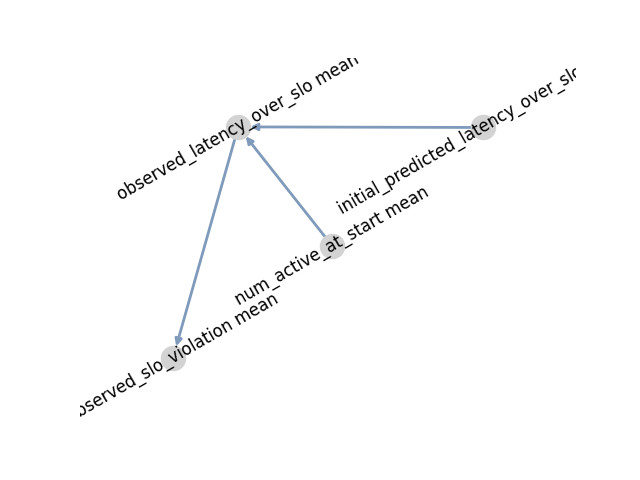

In [120]:
lg.accept('num_active_at_start mean', 'observed_latency_over_slo mean')
lg.accept('initial_predicted_latency_over_slo mean', 'observed_latency_over_slo mean')
lg.save_graph("/tmp/g.png") or Image("/tmp/g.png")

In [121]:
lg.get_adjusted_ate(
    "initial_predicted_latency_over_slo mean", "observed_latency_over_slo mean"
)

In [122]:
lg.get_causal_graph_refinement_suggestion(
    "initial_predicted_latency_over_slo mean", "observed_latency_over_slo mean"
)

('num_active_at_start mean', 'initial_predicted_latency_over_slo mean')

In [123]:
lg.accept('num_active_at_start mean', 'initial_predicted_latency_over_slo mean')
lg.get_adjusted_ate(
    "initial_predicted_latency_over_slo mean", "observed_latency_over_slo mean"
)